<a href="https://colab.research.google.com/github/Mark12481632/Functional-Programming/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simple Regression Techniques.**

In [38]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sb
import datetime as dt

In [39]:
sb.set()

**Get Stock data from Google and SPY**

In [21]:
tickers = "GOOG SPY"

end_date = dt.date.today()
start_date = end_date - dt.timedelta(365) # Ie 1 year ago.

In [24]:
# Download stock data
data = yf.download(tickers, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

# Extract closing prices
closing_prices = data['Adj Close']  # Adjusted Close accounts for all corporate actions

closing_prices.head()

[*********************100%%**********************]  2 of 2 completed


Ticker,GOOG,SPY
Date,,
2023-05-10,112.279999,406.956787
2023-05-11,116.900002,406.247070
2023-05-12,117.919998,405.714783
2023-05-15,116.959999,407.114502
2023-05-16,120.089996,404.393951


In [27]:
returns = np.log(closing_prices).diff().dropna()
returns.head()

Ticker,GOOG,SPY
Date,,
2023-05-11,0.040323,-0.001745
2023-05-12,0.008688,-0.001311
2023-05-15,-0.008174,0.003444
2023-05-16,0.026409,-0.006705
2023-05-17,0.011508,0.012066


In [30]:
samples = returns.sample(100).corr()
samples

Ticker,GOOG,SPY
Ticker,,
GOOG,1.000000,0.554458
SPY,0.554458,1.000000


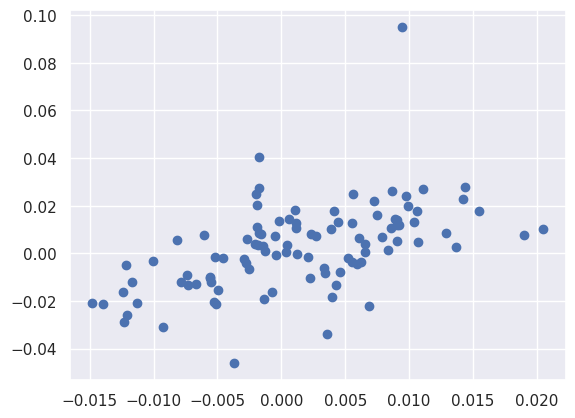

In [33]:
samples = returns.sample(100)
plt.scatter(x=samples['SPY'], y=samples['GOOG'])

In [34]:
reg = np.polyfit(samples['SPY'], samples['GOOG'], deg=1)
reg

array([1.25699286e+00, 5.94106683e-04])

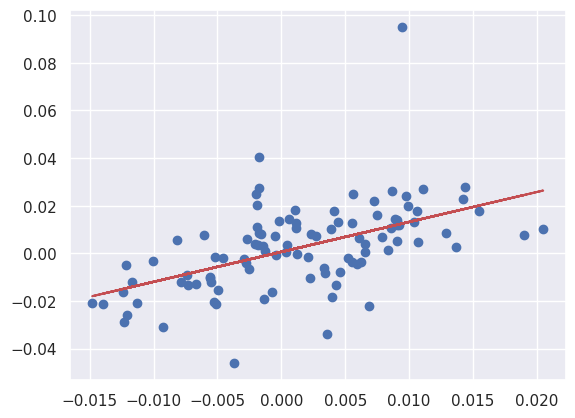

In [37]:
trend = np.polyval(reg, samples['SPY'])
plt.scatter(x=samples['SPY'], y=samples['GOOG'])
plt.plot(samples['SPY'], trend, 'r')